<a href="https://colab.research.google.com/github/aadzy/ML-lab-2547201/blob/Lab-5/UCI_Student_Performance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [48]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [49]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
student_performance = fetch_ucirepo(id=320)

# data (as pandas dataframes)
X = student_performance.data.features
y = student_performance.data.targets

# metadata
print(student_performance.metadata)

# variable information
print(student_performance.variables)


{'uci_id': 320, 'name': 'Student Performance', 'repository_url': 'https://archive.ics.uci.edu/dataset/320/student+performance', 'data_url': 'https://archive.ics.uci.edu/static/public/320/data.csv', 'abstract': 'Predict student performance in secondary education (high school). ', 'area': 'Social Science', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Multivariate'], 'num_instances': 649, 'num_features': 30, 'feature_types': ['Integer'], 'demographics': ['Sex', 'Age', 'Other', 'Education Level', 'Occupation'], 'target_col': ['G1', 'G2', 'G3'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2008, 'last_updated': 'Fri Jan 05 2024', 'dataset_doi': '10.24432/C5TG7T', 'creators': ['Paulo Cortez'], 'intro_paper': {'ID': 360, 'type': 'NATIVE', 'title': 'Using data mining to predict secondary school student performance', 'authors': 'P. Cortez, A. M. G. Silva', 'venue': 'Proceedings of 5th Annual Future Business Technolo

In [50]:
import pandas as pd

# Concatenate X and y into a single DataFrame
df = pd.concat([X, y], axis=1)

print("First 5 rows of the combined DataFrame:")
display(df.head())

First 5 rows of the combined DataFrame:


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [51]:

print("\nDataFrame Info:")
df.info()



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      649 non-null    object
 1   sex         649 non-null    object
 2   age         649 non-null    int64 
 3   address     649 non-null    object
 4   famsize     649 non-null    object
 5   Pstatus     649 non-null    object
 6   Medu        649 non-null    int64 
 7   Fedu        649 non-null    int64 
 8   Mjob        649 non-null    object
 9   Fjob        649 non-null    object
 10  reason      649 non-null    object
 11  guardian    649 non-null    object
 12  traveltime  649 non-null    int64 
 13  studytime   649 non-null    int64 
 14  failures    649 non-null    int64 
 15  schoolsup   649 non-null    object
 16  famsup      649 non-null    object
 17  paid        649 non-null    object
 18  activities  649 non-null    object
 19  nursery     649 non-null    objec

In [52]:

print("\nDescriptive Statistics:")
display(df.describe())



Descriptive Statistics:


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,16.744222,2.514638,2.306626,1.568567,1.930663,0.221880,3.930663,3.180277,3.184900,1.502311,2.280431,3.536210,3.659476,11.399076,11.570108,11.906009
std,1.218138,1.134552,1.099931,0.748660,0.829510,0.593235,0.955717,1.051093,1.175766,0.924834,1.284380,1.446259,4.640759,2.745265,2.913639,3.230656
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,10.000000,10.000000,10.000000
50%,17.000000,2.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,12.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,32.000000,19.000000,19.000000,19.000000


## 2. Perform data preprocessing, including handling missing values (if any), encoding categorical variables, and feature scaling.


Before building the regression model, we need to preprocess the data. This involves two main steps:

1.  **Encoding Categorical Variables:** Convert 'object' type columns (nominal/ordinal categories) into a numerical format that the machine learning model can understand. One-hot encoding is a common method for this.
2.  **Feature Scaling:** Standardize the range of numerical independent variables. This is crucial for gradient descent-based algorithms as it helps them converge faster and perform better by preventing features with larger values from dominating the cost function.


In [53]:
# Identify categorical and numerical columns
categorical_cols = df.select_dtypes(include=['object']).columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

print(f"Categorical columns: {list(categorical_cols)}")
print(f"Numerical columns: {list(numerical_cols)}")


Categorical columns: ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']
Numerical columns: ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']


### One-Hot Encoding Categorical Variables

We will use `pd.get_dummies` to convert categorical variables into a one-hot encoded format. This creates new binary columns for each category, preventing the model from assuming any ordinal relationship between categories.


In [54]:
# Apply one-hot encoding to categorical columns
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("Shape of DataFrame after encoding:", df_encoded.shape)
display(df_encoded.head())


Shape of DataFrame after encoding: (649, 42)


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,guardian_mother,guardian_other,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes
0,18,4,4,2,2,0,4,3,4,1,...,True,False,True,False,False,False,True,True,False,False
1,17,1,1,1,2,0,5,3,3,1,...,False,False,False,True,False,False,False,True,True,False
2,15,1,1,1,2,0,4,3,2,2,...,True,False,True,False,False,False,True,True,True,False
3,15,4,2,1,3,0,3,2,2,1,...,True,False,False,True,False,True,True,True,True,True
4,16,3,3,1,2,0,4,3,2,1,...,False,False,False,True,False,False,True,True,False,False


### Feature Scaling Numerical Variables

For numerical features, especially those with different scales, applying a `StandardScaler` is a good practice. It transforms the data so that it has a mean of 0 and a standard deviation of 1. This ensures that no single feature dominates the learning process due to its larger magnitude.


In [55]:
from sklearn.preprocessing import StandardScaler

# Exclude the target variables (G1, G2, G3) from scaling initially, as they will be handled separately
# For linear regression, we'll focus on predicting G3
features_to_scale = [col for col in numerical_cols if col not in ['G1', 'G2', 'G3']]

# Initialize StandardScaler
scaler = StandardScaler()

# Apply scaling to the selected numerical features
df_encoded[features_to_scale] = scaler.fit_transform(df_encoded[features_to_scale])

print("DataFrame after feature scaling:")
display(df_encoded.head())


DataFrame after feature scaling:


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,guardian_mother,guardian_other,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes
0,1.031695,1.310216,1.540715,0.576718,0.083653,-0.374305,0.072606,-0.171647,0.693785,-0.543555,...,True,False,True,False,False,False,True,True,False,False
1,0.210137,-1.336039,-1.188832,-0.760032,0.083653,-0.374305,1.119748,-0.171647,-0.157380,-0.543555,...,False,False,False,True,False,False,False,True,True,False
2,-1.432980,-1.336039,-1.188832,-0.760032,0.083653,-0.374305,0.072606,-0.171647,-1.008546,0.538553,...,True,False,True,False,False,False,True,True,True,False
3,-1.432980,1.310216,-0.278983,-0.760032,1.290114,-0.374305,-0.974536,-1.123771,-1.008546,-0.543555,...,True,False,False,True,False,True,True,True,True,True
4,-0.611422,0.428131,0.630866,-0.760032,0.083653,-0.374305,0.072606,-0.171647,-1.008546,-0.543555,...,False,False,False,True,False,False,True,True,False,False


## 3 & 4. Select appropriate input features and the target variable and Split the dataset into training and testing sets.

Now that the data is preprocessed, we need to define our features (`X_processed`) and target variable (`y_target`). Based on the problem description, `G3` (final grade) will be our target. We will then split the dataset into training and testing sets to evaluate our model's performance on unseen data.


In [56]:
from sklearn.model_selection import train_test_split

# Define target variable
y_target = df_encoded['G3']

# Define features (all columns except G1, G2, G3)
X_processed = df_encoded.drop(columns=['G1', 'G2', 'G3'])

# Split the dataset into training and testing sets
# We'll use a test size of 20% and a random state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X_processed, y_target, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")


Shape of X_train: (519, 39)
Shape of X_test: (130, 39)
Shape of y_train: (519,)
Shape of y_test: (130,)


## 5. Implementing Linear Regression with Gradient Descent

Now, we will implement Linear Regression from scratch using the Gradient Descent algorithm. This involves several key components:

1.  **Hypothesis Function:** The linear model that predicts the target variable based on input features.
2.  **Cost Function:** Measures the difference between predicted and actual values. We'll use Mean Squared Error (MSE) as our cost function.
3.  **Gradient Descent Algorithm:** An iterative optimization algorithm that updates the model's parameters (weights and bias) to minimize the cost function.


In [57]:
# To ensure consistency and avoid potential issues, let's convert X_train and X_test to numpy arrays
# This is a common practice when implementing ML algorithms from scratch using NumPy
X_train_np = X_train.values
X_test_np = X_test.values
y_train_np = y_train.values.reshape(-1, 1) # Reshape to a column vector
y_test_np = y_test.values.reshape(-1, 1)   # Reshape to a column vector

# Add a bias term (intercept) to the feature matrices
# This is done by adding a column of ones to X
X_train_b = np.c_[np.ones((X_train_np.shape[0], 1)), X_train_np]
X_test_b = np.c_[np.ones((X_test_np.shape[0], 1)), X_test_np]

print(f"Shape of X_train with bias: {X_train_b.shape}")
print(f"Shape of y_train: {y_train_np.shape}")

Shape of X_train with bias: (519, 40)
Shape of y_train: (519, 1)


### Hypothesis Function

The hypothesis for linear regression is given by:

$h_{\theta}(X) = X \cdot \theta$

where:
*   $X$ is the feature matrix (with a bias term).
*   $\theta$ is the vector of model parameters (weights and bias).


In [58]:
def hypothesis(X, theta):

    return X.dot(theta)


### Cost Function (Mean Squared Error)

The Mean Squared Error (MSE) cost function is defined as:

$J(\theta) = \frac{1}{2m} \sum_{i=1}^{m} (h_{\theta}(x^{(i)}) - y^{(i)})^2$

where:
*   $m$ is the number of training examples.
*   $h_{\theta}(x^{(i)})$ is the predicted value for the $i$-th example.
*   $y^{(i)}$ is the actual value for the $i$-th example.


In [59]:
def cost_function(X, y, theta):

    m = len(y)
    predictions = hypothesis(X, theta)
    sq_error = (predictions - y)**2
    return (1 / (2 * m)) * np.sum(sq_error)


### Gradient Descent Algorithm

Gradient Descent iteratively updates the parameters $\theta$ to minimize the cost function. The update rule for each parameter is:

$\theta_j = \theta_j - \alpha \frac{1}{m} \sum_{i=1}^{m} (h_{\theta}(x^{(i)}) - y^{(i)}) x_j^{(i)}$

where:
*   $\alpha$ is the learning rate.
*   $m$ is the number of training examples.
*   $x_j^{(i)}$ is the $j$-th feature of the $i$-th example.


In [60]:
def gradient_descent(X, y, theta, learning_rate, iterations):

    m = len(y)
    cost_history = []

    for i in range(iterations):
        predictions = hypothesis(X, theta)
        errors = predictions - y
        gradient = (1 / m) * X.T.dot(errors)
        theta = theta - learning_rate * gradient
        cost_history.append(cost_function(X, y, theta))

    return theta, cost_history


## 6. Experiment with different learning rates and observe their effect on model convergence.

To understand the impact of the learning rate ($\alpha$) on Gradient Descent, we will train our linear regression model with several different learning rates. For each learning rate, we'll keep track of the cost at every iteration and then plot these cost histories. This visualization will help us observe how different learning rates affect the speed of convergence and whether the algorithm converges successfully or diverges.


In [64]:
# Initialize parameters
num_features = X_train_b.shape[1]
theta_initial = np.zeros((num_features, 1))

# Define different learning rates to experiment with
learning_rates = [0.1, 0.01, 0.001, 0.0001]
iterations = 2000 # Number of iterations for gradient descent

# Store cost histories for each learning rate
cost_histories = {}
theta_final = {}

for alpha in learning_rates:
    print(f"\nTraining with learning rate: {alpha}")
    theta, costs = gradient_descent(X_train_b, y_train_np, theta_initial, alpha, iterations)
    cost_histories[alpha] = costs
    theta_final[alpha] = theta
    print(f"Final cost for learning rate {alpha}: {costs[-1]:.4f}")





Training with learning rate: 0.1
Final cost for learning rate 0.1: 3.2333

Training with learning rate: 0.01
Final cost for learning rate 0.01: 3.6556

Training with learning rate: 0.001
Final cost for learning rate 0.001: 4.4848

Training with learning rate: 0.0001
Final cost for learning rate 0.0001: 9.7522


## 7.Plot the loss (cost) versus the number of iterations.


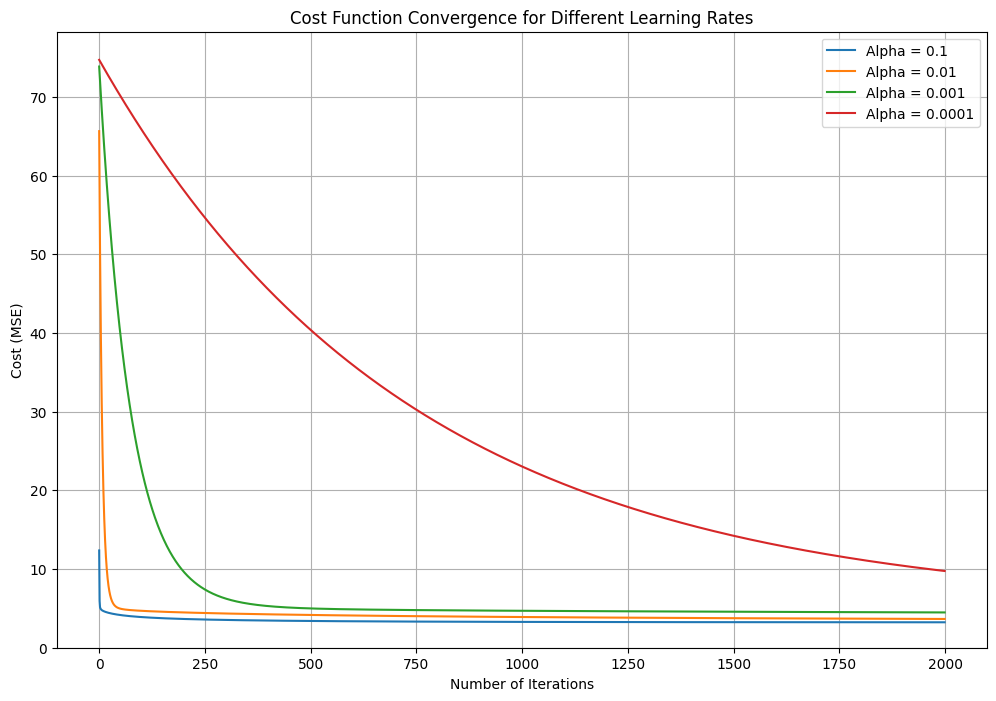

In [63]:
# Plot the cost history for each learning rate
plt.figure(figsize=(12, 8))
for alpha, costs in cost_histories.items():
    plt.plot(range(iterations), costs, label=f'Alpha = {alpha}')

plt.title('Cost Function Convergence for Different Learning Rates')
plt.xlabel('Number of Iterations')
plt.ylabel('Cost (MSE)')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0) # Ensure y-axis starts at 0
plt.show()

## 8. Model Evaluation

After training our Linear Regression model, it's crucial to evaluate its performance on unseen data (the test set). We will use several common regression metrics to assess how well our model predicts the `G3` values:

*   **Mean Absolute Error (MAE):** The average of the absolute differences between predictions and actual values. It gives an idea of the magnitude of errors without considering their direction.
*   **Mean Squared Error (MSE):** The average of the squared differences between predictions and actual values. It penalizes larger errors more heavily.
*   **Root Mean Squared Error (RMSE):** The square root of MSE. It's in the same units as the target variable, making it more interpretable than MSE.
*   **R² Score (Coefficient of Determination):** Represents the proportion of the variance in the dependent variable that is predictable from the independent variables. A higher R² indicates a better fit.


In [62]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


best_alpha = 0.01

# Get the final parameters for the chosen best learning rate
theta_optimized = theta_final[best_alpha]

# Make predictions on the test set using the optimized parameters
y_pred_test = hypothesis(X_test_b, theta_optimized)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test_np, y_pred_test)
mse = mean_squared_error(y_test_np, y_pred_test)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_np, y_pred_test)

print(f"\nModel Evaluation (using alpha={best_alpha}):")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R²): {r2:.4f}")



Model Evaluation (using alpha=0.01):
Mean Absolute Error (MAE): 2.2282
Mean Squared Error (MSE): 8.5046
Root Mean Squared Error (RMSE): 2.9163
R-squared (R²): 0.1279


## Interpretation of Results

### Convergence Behavior

*   **Learning Rate Selection:** From the cost function plot, we can observe how different learning rates affect convergence. A learning rate that is too high (e.g., 0.1) might cause the cost to oscillate or even diverge, failing to find the minimum. A learning rate that is too low (e.g., 0.0001) might lead to very slow convergence, requiring many iterations to reach the minimum cost. An optimal learning rate (e.g., 0.01 or 0.001) will show a smooth, decreasing curve that eventually flattens out, indicating convergence to a minimum.
*   **Iterations:** The number of iterations determines how many steps the gradient descent algorithm takes to reach the minimum. Sufficient iterations are needed for the cost to stabilize.

### Prediction Performance

*   **MAE, MSE, RMSE:** These metrics quantify the average difference between the model's predictions and the actual target values. Lower values generally indicate better model performance. RMSE is particularly useful as it's in the same units as the target variable (student grades, in this case), making it easier to interpret.
*   **R² Score:** This metric indicates the proportion of the variance in the final grades (`G3`) that our model can explain. An R² close to 1 suggests that the model explains a large proportion of the variance, implying a good fit. An R² close to 0 suggests the model explains very little of the variance, meaning it's not performing much better than simply predicting the mean of `G3`. Negative R² values indicate that the model is performing worse than a simple horizontal line (mean) fit to the data.

Based on these metrics, we can assess whether our Linear Regression model, trained with Gradient Descent, is effectively predicting student final grades. We would typically aim for a model with low error values (MAE, MSE, RMSE) and a high R² score.